<h1 style="font-size: 1.6rem; font-weight: bold">ITO 5221: Intelligent Image and Video Analysis</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Module 2.3: Machine Learning</h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---

### **Machine Learning Problem**

With the features extracted from images using the methods discussed previously, we can perform analysis such as classification. To frame this properly, we first need to understand the basic categories of machine learning.

Machine learning problems can be divided into four main types based on the **type of output** (discrete or continuous) and the **type of supervision** (supervised or unsupervised):

|  | **Supervised Learning** | **Unsupervised Learning** |
|---|---|---|
| **Discrete** | Classification or Categorisation | Clustering |
| **Continuous** | Regression | Dimensionality Reduction |

#### **Examples**
- **Classification** — classify an image as a dog or a cat
- **Regression** — predict the price of a house
- **Clustering** — group images into different categories without labels
- **Dimensionality reduction** — reduce the number of features while preserving important structure

#### **The Classification Problem**

For classification, we apply a **prediction function** to a feature representation of an image to produce the desired output. The question can be framed as:

$$y = f(\mathbf{x})$$

Where $f$ is the ML model, $\mathbf{x}$ is the feature vector extracted from the image, and $y$ is the predicted class label.

The next step is to let the model **learn** the relationship between input and output — this process is called **training**. There are many algorithms that can achieve this goal.

#### **Intuition**

At a conceptual level, imagine a 2D space where each data point is either an "O" or an "X". Each of these represents an image mapped to its feature vector. The goal of the ML model is to learn a **decision boundary** that correctly separates the "O"s from the "X"s. Training is the process of finding where that boundary should go based on the labelled examples we provide.

*** 

### **Bias-Variance Trade-off**

An ML model is trained on a dataset, but when applied to unseen data the results may be worse — because the model tries to "remember" the training data rather than learning general patterns. We want the model to **generalise** well so it performs reliably on new, unseen examples.

For example, imagine a training set and a test set where each row belongs to the same class. The test images differ slightly from the training images. If the model has learned the generalised relationship between features and labels, it will still predict correctly on the test set — this means the model is **robust**.

#### **Key Definitions**

- **Bias** — how much the average model across all training sets differs from the true model. High bias means the model is consistently wrong in a particular direction.
- **Variance** — how much models estimated from different training sets differ from each other. High variance means the model is sensitive to which specific data it was trained on.

#### **Underfitting vs Overfitting**

| | **Underfitting** | **Overfitting** |
|---|---|---|
| **Description** | Model is too "simple" to capture all relevant class characteristics | Model is too "complex" and fits irrelevant characteristics (noise) in the data |
| **Bias / Variance** | High bias, low variance | Low bias, high variance |
| **Training error** | High | Low |
| **Test error** | High | High |
| **Example** | Linear or logistic regression on nonlinear data | A deep decision tree trained on noisy data |

#### **The Dartboard Analogy**

Think of a dartboard where the bullseye represents the correct predictions. Each "hit" on the board is a prediction from a model trained on a different subset of data:

- **High bias, low variance** — the darts cluster tightly together but consistently miss the bullseye (underfitting)
- **Low bias, high variance** — the darts are scattered widely but their average is near the bullseye (overfitting)
- **Low bias, low variance** — the darts cluster tightly around the bullseye (the ideal model)

#### **The Trade-off**

As **model complexity increases**:
- **Training error** always decreases — a more complex model can always fit the training data better
- **Test error** decreases at first, then increases — beyond a certain point the model starts memorising noise rather than learning patterns

The **optimal complexity** is at the point where test error is lowest — the sweet spot between underfitting and overfitting.

#### **The Role of Training Data**

Overfitting can be mitigated by adding more training data:
- With **more training samples**, the test error stays low even as complexity increases
- With **fewer training samples**, the test error rises sharply with increased complexity

As the number of training samples grows, training error tends to increase slightly (the model can no longer perfectly memorise everything) while test error decreases (better generalisation). The gap between test error and training error is called the **generalisation error**.

#### **Three Ways to Reduce Variance and Avoid Overfitting**

1. **Choose a simpler classifier** — reduce model complexity
2. **Regularise the parameters** — add constraints that penalise overly complex models
3. **Get more training data** — more examples help the model learn general patterns instead of noise



*** 

### **K-Nearest Neighbour**

In the K-nearest neighbour algorithm, we treat all training instances as points positioned in n-dimensional space, each with a corresponding target value. A new instance gets classified by locating its k closest neighbours within this n-dimensional space and choosing the class label that appears most frequently among those neighbours. Each instance **x** = (v₁, v₂, ..., vₙ) has an associated target value **y**

#### **Classification Process for New Instance**
1. **Locate the closest neighbours**
2. **Conduct a majority vote from the neighbours**

#### **1-nearest neighbour**
Consider data points plotted in 2D space labeled as either orange or blue, with a new point currently shown in pink that needs classification.

Using 1-nearest neighbour, we identify the single closest point to the pink point, which happens to be a orange point. We perform a majority vote, resulting in orange classification, so we assign the pink point as orange.

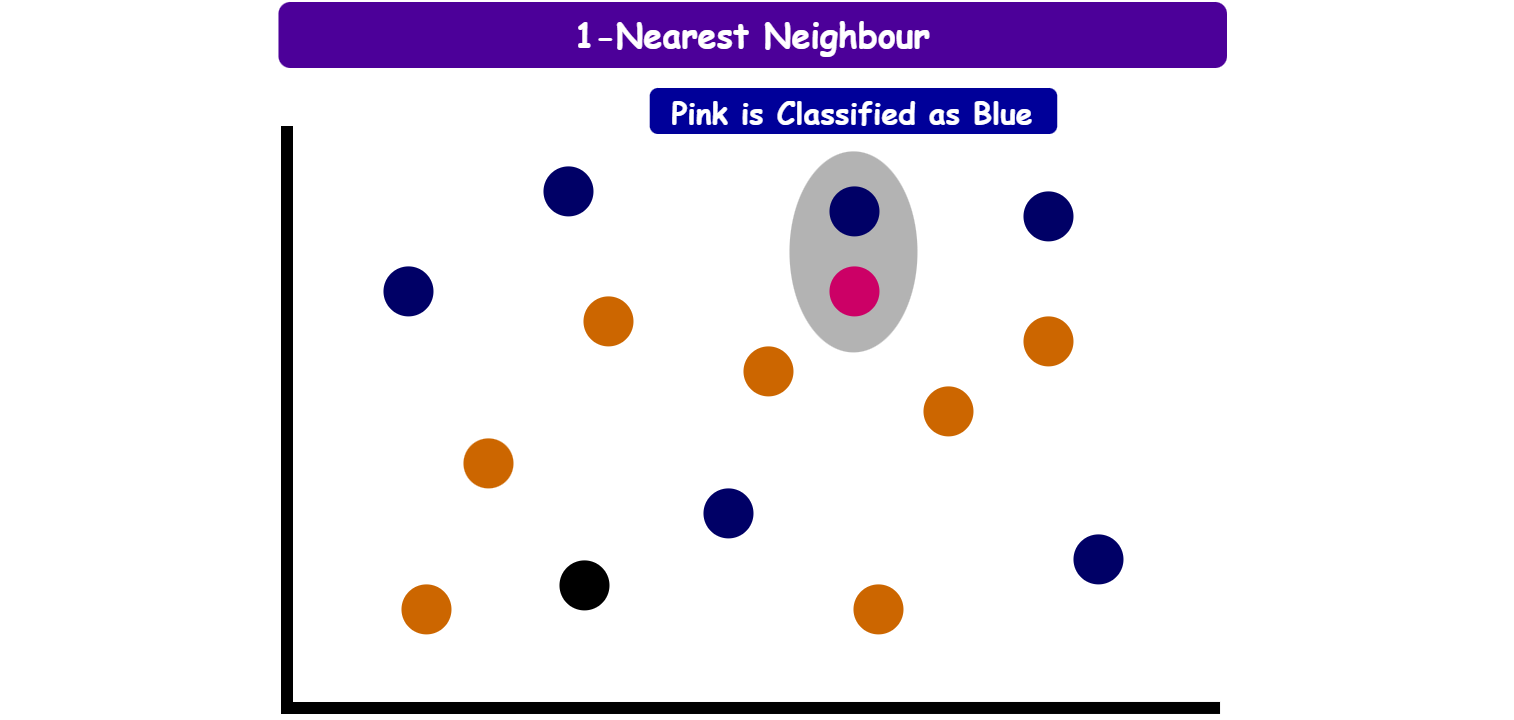

#### **3-nearest neighbour**
Alternatively, when applying 3-nearest neighbour, we search for the 3 closest points to our pink point and discover two blue points and one orange point. Consequently, our majority vote would classify the pink point as blue.

![image-2.png](attachment:image-2.png)

#### **Computing Similarity**

**Measuring distance between different instances**

When our data features are continuous, we apply Euclidean distance, and when our features are categorical, we use the Jaccard coefficient.

For instance, if an instance is represented by (v₁, v₂, ..., vₙ), vₖ represents the value of the k-th feature.

**Continuous features: Euclidean distance**
$$Ed(x_i, x_j) = \sqrt{\sum_{k=1}^{n}(v_{ik} - v_{jk})^2}$$

**Categorical features: Jaccard coefficient**
$$Jc(x_i, x_j) = \frac{|[v_{i1},...,v_{in}] \cap [v_{j1},...,v_{jn}]|}{|[v_{i1},...,v_{in}] \cup [v_{j1},...,v_{jn}]|}$$